# 02. DATA CLEANING - LÀM SẠCH VÀ XỬ LÝ DỮ LIỆU

**Mục tiêu:**
1. Overview dữ liệu trước khi làm sạch
2. Xác định và xử lý giá trị thiếu (Missing values)
3. Phát hiện và loại bỏ bản ghi trùng lặp (Duplicates)
4. Xử lý các giá trị ngoại lệ (Outliers)
5. Chuẩn hóa kiểu dữ liệu (Data types)
6. Chuẩn hóa và scale các features (Normalization & Scaling)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings

warnings.filterwarnings('ignore')

print("✅ Các thư viện đã sẵn sàng!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")


✅ Các thư viện đã sẵn sàng!
Pandas: 2.3.2
NumPy: 2.1.3


## 1. Tải và Khám Phá Dữ Liệu Gốc

Bắt đầu với một overview toàn bộ dữ liệu trước khi làm sạch.

In [2]:
# Tải dữ liệu đã gộp
df = pd.read_csv('../data/processed/spotify_merged_with_features.csv')

print("="*80)
print("📊 OVERVIEW DỮ LIỆU GỐC (CHƯA LÀM SẠCH)")
print("="*80)

# 1. Shape của dữ liệu
print(f"\n📈 Shape: {df.shape}")
print(f"   - Số dòng: {df.shape[0]:,}")
print(f"   - Số cột: {df.shape[1]}")

# 2. Các cột dữ liệu
print(f"\n📋 Các cột trong dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# 3. Kiểu dữ liệu
print(f"\n🔍 Kiểu dữ liệu:")
print(df.dtypes)

# 4. 5 dòng đầu tiên
print(f"\n👀 5 dòng đầu tiên:")
print(df.head())

# 5. Thông tin chi tiết
print(f"\n📊 Thông tin chi tiết:")
df.info()

# 6. Thống kê cơ bản
print(f"\n📈 Thống kê cơ bản (Numerical columns):")
print(df.describe())


📊 OVERVIEW DỮ LIỆU GỐC (CHƯA LÀM SẠCH)

📈 Shape: (17360, 32)
   - Số dòng: 17,360
   - Số cột: 32

📋 Các cột trong dataset:
    1. track_id
    2. track_name
    3. track_number
    4. track_popularity
    5. explicit
    6. artist_name
    7. artist_popularity
    8. artist_followers
    9. artist_genres
   10. album_id
   11. album_name
   12. album_release_date
   13. album_total_tracks
   14. album_type
   15. track_duration_min
   16. track_duration_ms
   17. uri
   18. track_href
   19. analysis_url
   20. type
   21. danceability
   22. energy
   23. key
   24. loudness
   25. mode
   26. speechiness
   27. acousticness
   28. instrumentalness
   29. liveness
   30. valence
   31. tempo
   32. time_signature

🔍 Kiểu dữ liệu:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres     


❓ PHÂN TÍCH GIÁ TRỊ THIẾU (MISSING VALUES)

⚠️ Các cột có giá trị thiếu:
            Column  Missing Count  Missing Percentage
track_duration_min           8778           50.564516
 track_duration_ms           8582           49.435484
     artist_genres           3365           19.383641
       artist_name              7            0.040323
 artist_popularity              4            0.023041
  artist_followers              4            0.023041
        track_name              2            0.011521
        album_name              2            0.011521


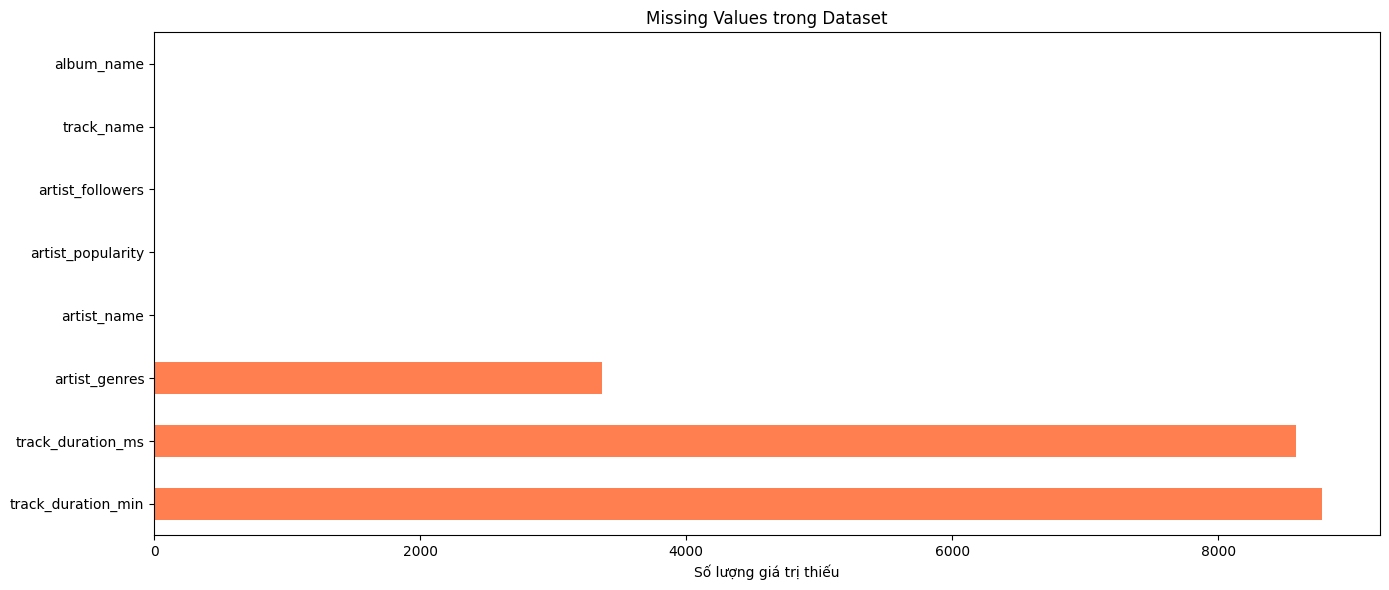

In [4]:
# Overview trực quan các giá trị thiếu
print("\n" + "="*80)
print("❓ PHÂN TÍCH GIÁ TRỊ THIẾU (MISSING VALUES)")
print("="*80)

# Đếm missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percentage', ascending=False)

if len(missing_df) > 0:
    print(f"\n⚠️ Các cột có giá trị thiếu:")
    print(missing_df.to_string(index=False))
else:
    print(f"\n✅ Không có giá trị thiếu!")

# Visualize missing values
fig, ax = plt.subplots(figsize=(14, 6))
missing_percent_sorted = missing_count[missing_count > 0].sort_values(ascending=False)
if len(missing_percent_sorted) > 0:
    missing_percent_sorted.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Số lượng giá trị thiếu')
    ax.set_title('Missing Values trong Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("Không có visualize vì không có missing values")


## 2. Xử Lý Giá Trị Thiếu (Missing Values)

In [5]:
df_clean = df.copy()

print("="*80)
print("🔧 XỬ LÝ GIÁTRỊ THIẾU")
print("="*80)

# Xử lý các cột có missing values
print(f"\n📊 Trước khi xử lý: {df_clean.isnull().sum().sum()} giá trị thiếu")

# Chiến lược:
# 1. Các cột numerical: Fill bằng median
# 2. Các cột categorical: Fill bằng mode hoặc 'Unknown'
# 3. Các cột có quá nhiều missing (>50%): Xóa cột

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# Xử lý numerical columns
for col in numerical_cols:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        missing_percent = (missing_count / len(df_clean)) * 100
        if missing_percent > 50:
            print(f"\n❌ Xóa cột '{col}': {missing_percent:.2f}% giá trị thiếu (quá nhiều)")
            df_clean = df_clean.drop(col, axis=1)
        else:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"\n✅ Điền cột '{col}': {missing_count} giá trị → median = {median_val:.2f}")

# Xử lý categorical columns
for col in categorical_cols:
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        missing_percent = (missing_count / len(df_clean)) * 100
        if missing_percent > 50:
            print(f"\n❌ Xóa cột '{col}': {missing_percent:.2f}% giá trị thiếu (quá nhiều)")
            df_clean = df_clean.drop(col, axis=1)
        else:
            mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown'
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"\n✅ Điền cột '{col}': {missing_count} giá trị → mode = '{mode_val}'")

print(f"\n\n📊 Sau khi xử lý: {df_clean.isnull().sum().sum()} giá trị thiếu")
print(f"✅ Shape mới: {df_clean.shape}")


🔧 XỬ LÝ GIÁTRỊ THIẾU

📊 Trước khi xử lý: 20744 giá trị thiếu

✅ Điền cột 'artist_popularity': 4 giá trị → median = 74.00

✅ Điền cột 'artist_followers': 4 giá trị → median = 6141719.00

❌ Xóa cột 'track_duration_min': 50.56% giá trị thiếu (quá nhiều)

✅ Điền cột 'track_duration_ms': 8582 giá trị → median = 207276.00

✅ Điền cột 'track_name': 2 giá trị → mode = 'Flowers'

✅ Điền cột 'artist_name': 7 giá trị → mode = 'Taylor Swift'

✅ Điền cột 'artist_genres': 3365 giá trị → mode = '[]'

✅ Điền cột 'album_name': 2 giá trị → mode = 'Nevermind (Super Deluxe Edition)'


📊 Sau khi xử lý: 0 giá trị thiếu
✅ Shape mới: (17360, 31)


## 3. Phát Hiện và Xóa Bản Ghi Trùng Lặp (Duplicates)

In [6]:
print("="*80)
print("🔍 PHÁT HIỆN VÀ XÓA BẢN GHI TRÙNG LẶP")
print("="*80)

# Kiểm tra duplicates toàn bộ
full_duplicates = df_clean.duplicated().sum()
print(f"\n🔎 Bản ghi trùng lặp (toàn bộ cột): {full_duplicates}")

# Kiểm tra duplicates theo track_id
if 'track_id' in df_clean.columns:
    track_duplicates = df_clean.duplicated(subset=['track_id']).sum()
    print(f"🔎 Bản ghi trùng lặp (theo track_id): {track_duplicates}")
    
    if track_duplicates > 0:
        print("\n📋 Ví dụ bản ghi trùng:")
        print(df_clean[df_clean.duplicated(subset=['track_id'], keep=False)][['track_id', 'track_name', 'artist_name']].head(10))

# Xóa duplicates
if full_duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"\n✅ Đã xóa {full_duplicates} bản ghi trùng lặp")

print(f"\n📊 Shape sau xóa duplicates: {df_clean.shape}")


🔍 PHÁT HIỆN VÀ XÓA BẢN GHI TRÙNG LẶP

🔎 Bản ghi trùng lặp (toàn bộ cột): 0
🔎 Bản ghi trùng lặp (theo track_id): 8582

📋 Ví dụ bản ghi trùng:
                 track_id                                       track_name  \
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2  7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3  67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4  15xptTfRBrjsppW0INUZjf                            ride me like a harley   
5  4ccpCcZYseq8VrPMK1EDs0                                            BLEED   
6  3QoQ3HqXTAjgEl9LbNMbYp                             Te Procuro na Cidade   
7  1YEZbdT417SfolPQzaoHs2                                      come closer   
8  4pZ949nFW5SurwzE0TSe7I                                 Cupido Vagabundo   
9  0L0LgwFZ7UtBnRNQvSBty6                                        LET’S GO!   



## 4. Phát Hiện và Xử Lý Giá Trị Ngoại Lệ (Outliers)

In [8]:
print("="*80)
print("🎯 PHÁT HIỆN VÀ XỬ LÝ GIÁ TRỊ NGOẠI LỆ (IQR METHOD)")
print("="*80)

# Lấy các cột numerical (audio features)
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Chọn audio features chính để detect outliers
audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
audio_features = [f for f in audio_features if f in numeric_features]

print(f"\n🔍 Phát hiện outliers cho {len(audio_features)} audio features:")

outlier_count_before = len(df_clean)

# Sử dụng IQR method để phát hiện outliers
for col in audio_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df_clean)) * 100
    
    if len(outliers) > 0:
        print(f"\n   • '{col}':")
        print(f"     - Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"     - Outliers: {len(outliers)} ({outlier_pct:.2f}%)")

# Xử lý outliers: Thay thế bằng IQR bounds (capping)
print(f"\n\n🔧 Capping outliers bằng IQR method...")

df_capped = df_clean.copy()

for col in audio_features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values
    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)

print("✅ Capping hoàn tất")

# Không xóa outliers, chỉ cap
df_clean = df_capped

print(f"\n📊 Shape sau xử lý outliers: {df_clean.shape}")


🎯 PHÁT HIỆN VÀ XỬ LÝ GIÁ TRỊ NGOẠI LỆ (IQR METHOD)

🔍 Phát hiện outliers cho 9 audio features:


🔧 Capping outliers bằng IQR method...
✅ Capping hoàn tất

📊 Shape sau xử lý outliers: (17360, 31)


## 5. Chuẩn Hóa Kiểu Dữ Liệu (Data Type Standardization)

In [9]:
print("="*80)
print("📝 CHUẨN HÓA KIỂU DỮ LIỆU")
print("="*80)

print("\n🔍 Kiểu dữ liệu hiện tại:")
print(df_clean.dtypes)

# Chuẩn hóa kiểu dữ liệu
print("\n🔧 Chuẩn hóa kiểu dữ liệu...")

# Các cột nên là integer
int_cols = ['track_number', 'key', 'mode', 'time_signature']
for col in int_cols:
    if col in df_clean.columns and df_clean[col].dtype != 'int64':
        df_clean[col] = df_clean[col].astype('int64')
        print(f"   ✅ '{col}' → int64")

# Các cột nên là float
float_cols = [
    'track_popularity', 'artist_popularity', 'artist_followers',
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
for col in float_cols:
    if col in df_clean.columns and df_clean[col].dtype != 'float64':
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"   ✅ '{col}' → float64")

# Các cột string
str_cols = ['track_id', 'track_name', 'artist_name', 'album_id', 'artist_genres']
for col in str_cols:
    if col in df_clean.columns and df_clean[col].dtype != 'object':
        df_clean[col] = df_clean[col].astype('object')
        print(f"   ✅ '{col}' → object (string)")

print(f"\n✅ Chuẩn hóa hoàn tất")
print(f"\n📝 Kiểu dữ liệu sau chuẩn hóa:")
print(df_clean.dtypes)


📝 CHUẨN HÓA KIỂU DỮ LIỆU

🔍 Kiểu dữ liệu hiện tại:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_ms     float64
uri                    object
track_href             object
analysis_url           object
type                   object
danceability          float64
energy                float64
key                     int64
loudness              float64
mode                    int64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature          int64
dtype: object

🔧 Ch

## 6. Chuẩn Hóa và Scale Các Features (Normalization & Scaling)

📊 CHUẨN HÓA VÀ SCALE AUDIO FEATURES

📈 Các features sẽ được scale: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']


📊 Thống kê TRƯỚC scaling:
       danceability        energy      loudness   speechiness  acousticness  \
count  17360.000000  17360.000000  17360.000000  17360.000000  17360.000000   
mean       0.503272      0.496117    -30.353095      0.502191      0.499288   
std        0.286961      0.287868     17.257965      0.289407      0.288064   
min        0.000012      0.000124    -59.999678      0.000019      0.000097   
25%        0.258042      0.246642    -45.528608      0.251941      0.251312   
50%        0.508364      0.490105    -30.165151      0.500697      0.498495   
75%        0.750012      0.747818    -15.666152      0.754625      0.747794   
max        0.999611      0.999772     -0.012181      0.999944      0.999934   

       instrumentalness      liveness       valence         tempo  
cou

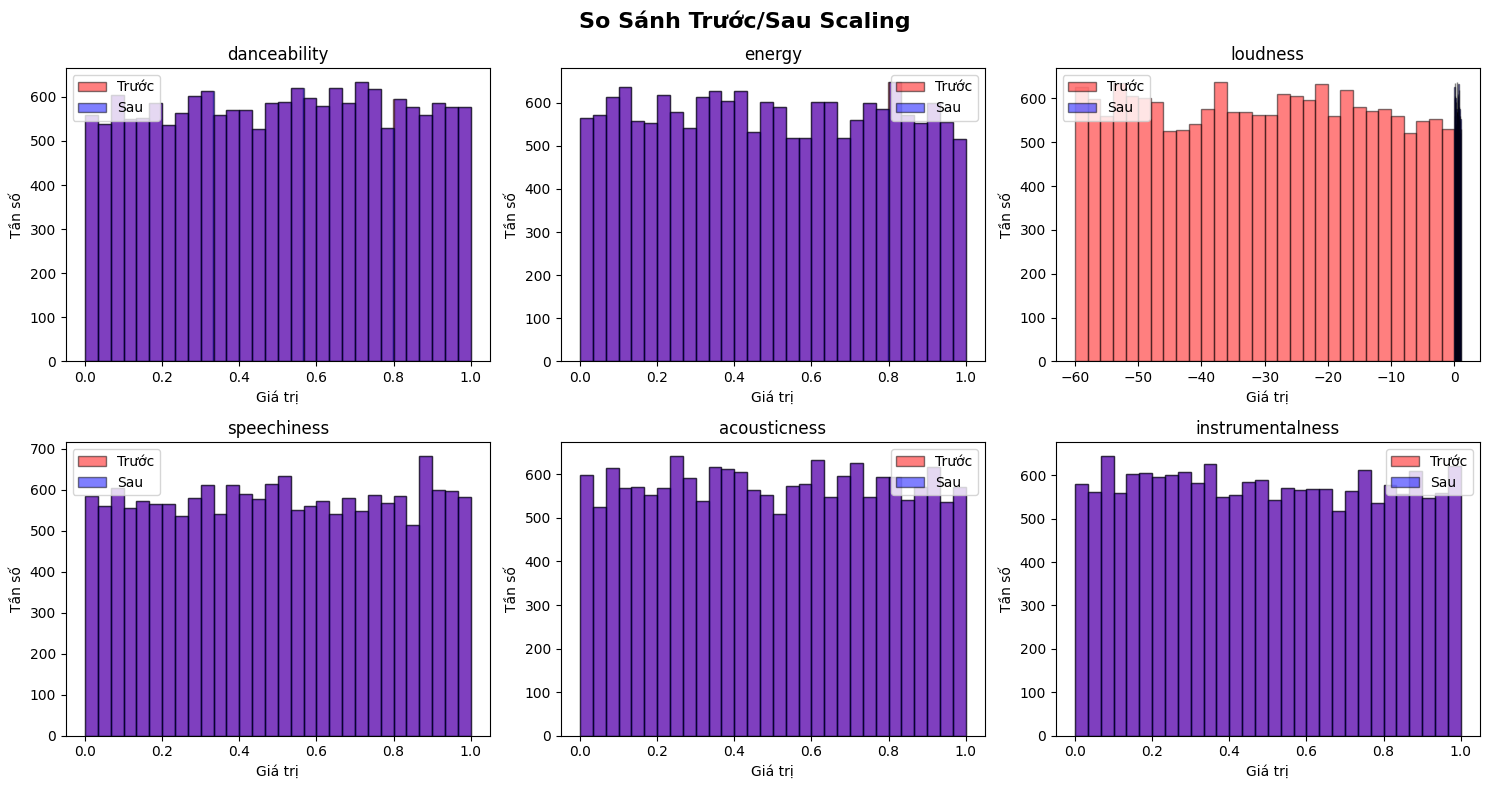


✅ Visualization hoàn tất


In [10]:
print("="*80)
print("📊 CHUẨN HÓA VÀ SCALE AUDIO FEATURES")
print("="*80)

# Audio features cần scaling
audio_features_to_scale = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
audio_features_to_scale = [f for f in audio_features_to_scale if f in df_clean.columns]

print(f"\n📈 Các features sẽ được scale: {audio_features_to_scale}")

# Hiển thị thống kê trước scaling
print(f"\n\n📊 Thống kê TRƯỚC scaling:")
print(df_clean[audio_features_to_scale].describe())

# Áp dụng MinMaxScaler (scale về [0, 1])
print(f"\n\n🔧 Áp dụng MinMaxScaler (scale về [0, 1])...")

scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[audio_features_to_scale] = scaler.fit_transform(df_clean[audio_features_to_scale])

print("✅ Scaling hoàn tất")

# Hiển thị thống kê sau scaling
print(f"\n📊 Thống kê SAU scaling:")
print(df_scaled[audio_features_to_scale].describe())

# Visualize trước/sau scaling
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('So Sánh Trước/Sau Scaling', fontsize=16, fontweight='bold')

features_to_plot = audio_features_to_scale[:6]

for idx, col in enumerate(features_to_plot):
    row = idx // 3
    col_idx = idx % 3
    
    ax = axes[row, col_idx]
    
    ax.hist(df_clean[col], bins=30, alpha=0.5, label='Trước', color='red', edgecolor='black')
    ax.hist(df_scaled[col], bins=30, alpha=0.5, label='Sau', color='blue', edgecolor='black')
    
    ax.set_title(f'{col}')
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Tần số')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n✅ Visualization hoàn tất")


## 7. Tóm Tắt Kết Quả Làm Sạch Dữ Liệu

In [11]:
print("\n" + "="*80)
print("📋 TÓM TẮT KẾT QUẢ LÀM SẠCH DỮ LIỆU")
print("="*80)

print(f"\n📊 So sánh trước/sau:")
print(f"   Trước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"   Sau:   {df_clean.shape[0]:,} dòng × {df_clean.shape[1]} cột")
print(f"   Thay đổi: {df.shape[0] - df_clean.shape[0]:,} dòng bị loại ({((df.shape[0] - df_clean.shape[0])/df.shape[0]*100):.2f}%)")

print(f"\n🎯 Các bước thực hiện:")
print(f"   ✅ Xử lý giá trị thiếu (Missing values)")
print(f"   ✅ Xóa bản ghi trùng lặp (Duplicates)")
print(f"   ✅ Xử lý giá trị ngoại lệ (Outliers - IQR capping)")
print(f"   ✅ Chuẩn hóa kiểu dữ liệu (Data types)")
print(f"   ✅ Scale audio features (MinMaxScaler)")

print(f"\n📝 Kiểu dữ liệu sau chuẩn hóa:")
print(df_clean.dtypes)

print(f"\n\n💾 Lưu dữ liệu đã làm sạch...")

# Lưu dữ liệu gốc đã làm sạch (không scale)
output_path_clean = '../data/processed/spotify_cleaned.csv'
df_clean.to_csv(output_path_clean, index=False)
print(f"   ✅ Dữ liệu gốc: {output_path_clean}")

# Lưu dữ liệu đã scale
output_path_scaled = '../data/processed/spotify_cleaned_scaled.csv'
df_scaled.to_csv(output_path_scaled, index=False)
print(f"   ✅ Dữ liệu đã scale: {output_path_scaled}")

print(f"\n🎉 Làm sạch dữ liệu hoàn tất!")



📋 TÓM TẮT KẾT QUẢ LÀM SẠCH DỮ LIỆU

📊 So sánh trước/sau:
   Trước: 17,360 dòng × 32 cột
   Sau:   17,360 dòng × 31 cột
   Thay đổi: 0 dòng bị loại (0.00%)

🎯 Các bước thực hiện:
   ✅ Xử lý giá trị thiếu (Missing values)
   ✅ Xóa bản ghi trùng lặp (Duplicates)
   ✅ Xử lý giá trị ngoại lệ (Outliers - IQR capping)
   ✅ Chuẩn hóa kiểu dữ liệu (Data types)
   ✅ Scale audio features (MinMaxScaler)

📝 Kiểu dữ liệu sau chuẩn hóa:
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity     float64
artist_followers      float64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_ms     float64
uri                    object
track_href             object
analysis_url           object
type                   object
dan